In [ ]:
!pip install -q fvcore seaborn 2>/dev/null

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms as T
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
import time
import os
import gc
import pickle
import warnings
from pathlib import Path
from tqdm import tqdm
import sys
import urllib.request
import tarfile

warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def verify_environment():
    """Comprehensive environment verification."""
    print("="*80)
    print("🔍 ENVIRONMENT VERIFICATION")
    print("="*80)

    # PyTorch version
    print(f"\n📦 PyTorch: {torch.__version__}")
    print(f"📦 Torchvision: {torchvision.__version__}")
    print(f"📦 Python: {sys.version.split()[0]}")

    # GPU check
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"\n✅ GPU Available: {gpu_name}")
        print(f"   Memory: {gpu_memory:.1f} GB")
        print(f"   CUDA: {torch.version.cuda}")

        # Quick GPU consistency check
        print("\n🔄 Running GPU consistency check...")
        dummy = torch.randn(1000, 1000, device='cuda')
        times = []
        for _ in range(100):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = dummy @ dummy.T
            torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

        cv = np.std(times) / np.mean(times)
        if cv < 0.05:
            print(f"   GPU consistency CV: {cv:.4f} ✅ Stable")
        else:
            print(f"   GPU consistency CV: {cv:.4f} ⚠️ High variance detected")

        return gpu_name, gpu_memory
    else:
        raise RuntimeError("❌ GPU not available! Go to Runtime > Change runtime type > GPU")

GPU_NAME, GPU_MEMORY = verify_environment()

# Create output directories
OUTPUT_DIR = Path('/content/benchmark_results')
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'plots').mkdir(exist_ok=True)
(OUTPUT_DIR / 'checkpoints').mkdir(exist_ok=True)

print(f"\n📁 Output directory: {OUTPUT_DIR}")
print(f"✅ Environment ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.2 MB/s eta 0:00:00
🔍 ENVIRONMENT VERIFICATION

📦 PyTorch: 2.11.0+cu128
📦 Torchvision: 0.26.0+cu128
📦 Python: 3.12.13

✅ GPU Available: Tesla T4
   Memory: 15.6 GB
   CUDA: 12.8

🔄 Running GPU consistency check...
   GPU consistency CV: 6.6516 ⚠️ High variance detected

📁 Output directory: /content/benchmark_results
✅ Environment ready!


In [ ]:
class Config:
    """Benchmarking configuration."""

    # Dataset
    DATASET_ROOT = '/content/data'
    NUM_CLASSES = 21  # 20 VOC classes + background
    IGNORE_INDEX = 255

    # Resolution sweep
    RESOLUTIONS = [256, 384, 512, 640]

    # Timing
    WARMUP_RUNS = 30
    LATENCY_RUNS = 100
    BATCH_SIZE = 1

    # Model configurations - All with ResNet50 backbone for fair comparison
    MODELS = OrderedDict([
        # DeepLabV3 variants
        ('DeepLabV3-ResNet50', {
            'model_fn': torchvision.models.segmentation.deeplabv3_resnet50,
            'weights': 'COCO_WITH_VOC_LABELS_V1',
            'family': 'DeepLabV3',
            'backbone': 'ResNet-50'
        }),

        # FCN variants
        ('FCN-ResNet50', {
            'model_fn': torchvision.models.segmentation.fcn_resnet50,
            'weights': 'COCO_WITH_VOC_LABELS_V1',
            'family': 'FCN',
            'backbone': 'ResNet-50'
        }),

        # Lightweight models
        ('DeepLabV3-MobileNetV3', {
            'model_fn': torchvision.models.segmentation.deeplabv3_mobilenet_v3_large,
            'weights': 'COCO_WITH_VOC_LABELS_V1',
            'family': 'DeepLabV3',
            'backbone': 'MobileNetV3-Large'
        }),

        ('LRASPP-MobileNetV3', {
            'model_fn': torchvision.models.segmentation.lraspp_mobilenet_v3_large,
            'weights': 'COCO_WITH_VOC_LABELS_V1',
            'family': 'LRASPP',
            'backbone': 'MobileNetV3-Large'
        }),
    ])

    # Normalization (ImageNet stats - REQUIRED for pre-trained models)
    MEAN = [0.485, 0.456, 0.406]
    STD = [0.229, 0.224, 0.225]

    # VOC class names
    VOC_CLASSES = [
        'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
        'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog',
        'horse', 'motorbike', 'person', 'pottedplant', 'sheep',
        'sofa', 'train', 'tvmonitor'
    ]

config = Config()
print("✅ Configuration loaded")
print(f"   Models to benchmark: {len(config.MODELS)}")
print(f"   Resolutions: {config.RESOLUTIONS}")
print(f"   Warmup runs: {config.WARMUP_RUNS}")
print(f"   Timing runs: {config.LATENCY_RUNS}")


✅ Configuration loaded
   Models to benchmark: 4
   Resolutions: [256, 384, 512, 640]
   Warmup runs: 30
   Timing runs: 100


In [ ]:
def download_voc_dataset(root):
    """
    Download PASCAL VOC 2012 dataset with progress tracking.
    This will automatically download both images and annotations.
    """
    print("\n" + "="*80)
    print("📥 DATASET DOWNLOAD & PREPARATION")
    print("="*80)

    root = Path(root)
    root.mkdir(parents=True, exist_ok=True)

    # Check if dataset already exists
    dataset_dir = root / 'VOCdevkit' / 'VOC2012'
    if dataset_dir.exists() and (dataset_dir / 'JPEGImages').exists():
        print(f"\n✅ Dataset already exists at {dataset_dir}")
        # Count images
        n_images = len(list((dataset_dir / 'JPEGImages').glob('*.jpg')))
        print(f"   Found {n_images} images")
        return str(dataset_dir.parent)

    print("\n📥 Downloading PASCAL VOC 2012 dataset...")
    print("   This may take 5-10 minutes depending on your connection...")

    # Download using torchvision (automatic)
    try:
        # This triggers the automatic download
        dataset = torchvision.datasets.VOCSegmentation(
            root=str(root),
            year='2012',
            image_set='train',  # Use train to trigger download
            download=True,
            transform=None,
            target_transform=None
        )

        # Also download validation set
        dataset_val = torchvision.datasets.VOCSegmentation(
            root=str(root),
            year='2012',
            image_set='val',
            download=True,
            transform=None,
            target_transform=None
        )

        print(f"\n✅ Dataset downloaded successfully!")
        print(f"   Training images: {len(dataset)}")
        print(f"   Validation images: {len(dataset_val)}")

        return str(root / 'VOCdevkit')

    except Exception as e:
        print(f"\n❌ Automatic download failed: {e}")
        print("   Attempting manual download...")

        # Manual download fallback
        url = "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"
        tar_path = root / "VOCtrainval_11-May-2012.tar"

        try:
            # Download with progress bar
            print(f"   Downloading from {url}")
            urllib.request.urlretrieve(url, tar_path)

            # Extract
            print("   Extracting files...")
            with tarfile.open(tar_path) as tar:
                tar.extractall(path=root)

            # Cleanup
            tar_path.unlink()

            print("✅ Manual download successful!")
            return str(root / 'VOCdevkit')

        except Exception as e2:
            raise RuntimeError(f"Both automatic and manual download failed: {e2}")

# Download dataset
VOC_ROOT = download_voc_dataset(config.DATASET_ROOT)

# Verify dataset
print("\n🔍 Verifying dataset structure...")
dataset_dir = Path(VOC_ROOT) / 'VOC2012'
required_dirs = ['JPEGImages', 'SegmentationClass', 'ImageSets/Segmentation']
all_ok = True
for d in required_dirs:
    full_path = dataset_dir / d
    if full_path.exists():
        count = len(list(full_path.glob('*.*' if '.' not in d else '*.txt')))
        print(f"   ✅ {d}: {count} files")
    else:
        print(f"   ❌ {d}: MISSING!")
        all_ok = False

if not all_ok:
    raise RuntimeError("Dataset structure incomplete!")

print("\n✅ Dataset ready for benchmarking!")



📥 DATASET DOWNLOAD & PREPARATION

📥 Downloading PASCAL VOC 2012 dataset...
   This may take 5-10 minutes depending on your connection...


100%|██████████| 2.00G/2.00G [01:51<00:00, 17.9MB/s]



✅ Dataset downloaded successfully!
   Training images: 1464
   Validation images: 1449

🔍 Verifying dataset structure...
   ✅ JPEGImages: 17125 files
   ✅ SegmentationClass: 2913 files
   ✅ ImageSets/Segmentation: 3 files

✅ Dataset ready for benchmarking!


In [5]:
class mIoUMetric:
    """
    Mean Intersection over Union calculator.
    Handles void class (255) correctly.
    """

    def __init__(self, num_classes=21, ignore_index=255):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.intersection = torch.zeros(self.num_classes, dtype=torch.float64)
        self.union = torch.zeros(self.num_classes, dtype=torch.float64)
        self.class_present = torch.zeros(self.num_classes, dtype=torch.bool)

    def update(self, pred, target):
        """
        Update metrics with a single prediction-target pair.

        Args:
            pred: (H, W) tensor of predicted class indices
            target: (H, W) tensor of ground truth class indices
        """
        # Ensure correct types and devices
        pred = pred.cpu()
        target = target.cpu()

        for cls in range(self.num_classes):
            pred_mask = (pred == cls)
            target_mask = (target == cls)
            valid_mask = (target != self.ignore_index)

            # Intersection: pixels where both predict and target agree on this class
            # AND the target pixel is not ignored
            intersection = (pred_mask & target_mask & valid_mask).sum().float()

            # Union: pixels where either predict or target has this class
            # AND the target pixel is not ignored
            union = ((pred_mask | target_mask) & valid_mask).sum().float()

            self.intersection[cls] += intersection.double()
            self.union[cls] += union.double()

            # Track if class appears in valid regions
            if (target_mask & valid_mask).any():
                self.class_present[cls] = True

    def compute(self, ignore_missing=True):
        """
        Compute mIoU.

        Args:
            ignore_missing: If True, only average over classes present in dataset

        Returns:
            float: mean IoU score
        """
        # Avoid division by zero
        ious = self.intersection / (self.union + 1e-10)

        if ignore_missing:
            # Only average over classes present in dataset
            valid_ious = ious[self.class_present]
            if len(valid_ious) > 0:
                return valid_ious.mean().item()
            return 0.0
        else:
            return ious.mean().item()

    def per_class_iou(self):
        """Return per-class IoU values."""
        return (self.intersection / (self.union + 1e-10)).numpy()

class SegmentationMetrics:
    """Comprehensive metrics for segmentation models."""

    @staticmethod
    def compute_flops(model, input_shape=(1, 3, 512, 512)):
        """Compute FLOPs using fvcore."""
        try:
            from fvcore.nn import FlopCountAnalysis
            input_tensor = torch.randn(input_shape)
            flops = FlopCountAnalysis(model, input_tensor)
            return flops.total() / 1e9  # GFLOPs
        except Exception as e:
            print(f"   ⚠️ Could not compute FLOPs: {e}")
            return None

    @staticmethod
    def count_parameters(model):
        """Count trainable parameters."""
        return sum(p.numel() for p in model.parameters()) / 1e6  # Millions

    @staticmethod
    def get_model_size(model):
        """Get model file size in MB."""
        torch.save(model.state_dict(), '/tmp/model_temp.pth')
        size = os.path.getsize('/tmp/model_temp.pth') / 1e6
        os.remove('/tmp/model_temp.pth')
        return size


In [6]:

def load_model_weights(model_fn, weights_name):
    """
    Load model with proper weight handling for different torchvision versions.
    """
    try:
        # Try new API (torchvision >= 0.14)
        import torchvision.models.segmentation as seg_models

        weight_map = {
            'COCO_WITH_VOC_LABELS_V1': {
                'deeplabv3_resnet50': seg_models.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1,
                'deeplabv3_mobilenet_v3_large': seg_models.DeepLabV3_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1,
                'fcn_resnet50': seg_models.FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1,
                'lraspp_mobilenet_v3_large': seg_models.LRASPP_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1,
            }
        }

        # Get model function name
        fn_name = model_fn.__name__ if hasattr(model_fn, '__name__') else str(model_fn)

        # Find matching weight
        weight = None
        for model_key, model_weight in weight_map.get(weights_name, {}).items():
            if model_key in fn_name:
                weight = model_weight
                break

        if weight:
            model = model_fn(weights=weight)
        else:
            model = model_fn(weights=weights_name)

    except:
        # Fallback for older torchvision
        try:
            model = model_fn(pretrained=True)
        except:
            model = model_fn(pretrained_backbone=True)

    return model

def prepare_model(model_name, model_config):
    """Load and prepare a segmentation model."""
    print(f"   Loading {model_name}...", end=' ')

    model = load_model_weights(model_config['model_fn'], model_config['weights'])
    model.eval()
    model = model.to('cuda')

    # Count parameters
    params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"✅ ({params:.1f}M params)")

    return model

def reset_gpu():
    """Clean GPU memory."""
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    gc.collect()


In [7]:
def benchmark_accuracy(model, model_name, config):
    """
    Compute mIoU across all resolutions.
    Uses proper handling of void class (255).
    """
    print(f"\n{'='*80}")
    print(f"📊 ACCURACY BENCHMARK: {model_name}")
    print(f"{'='*80}")

    results = {}

    for resolution in config.RESOLUTIONS:
        print(f"\n   Resolution: {resolution}×{resolution}")

        # Create resolution-specific dataset
        transform = T.Compose([
            T.Resize((resolution, resolution), interpolation=T.InterpolationMode.BILINEAR),
            T.ToTensor(),
            T.Normalize(mean=config.MEAN, std=config.STD)
        ])

        def target_transform(target):
            # Convert PIL image to tensor with NEAREST interpolation
            target = torch.as_tensor(np.array(target), dtype=torch.int64)
            target = T.Resize(
                (resolution, resolution),
                interpolation=T.InterpolationMode.NEAREST
            )(target.unsqueeze(0)).squeeze(0)
            return target

        # Load dataset (no download needed, already downloaded)
        dataset = torchvision.datasets.VOCSegmentation(
            root=config.DATASET_ROOT,
            year='2012',
            image_set='val',
            download=False,  # Already downloaded
            transform=transform,
            target_transform=target_transform
        )

        dataloader = DataLoader(
            dataset,
            batch_size=1,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        # Compute mIoU
        metric = mIoUMetric(num_classes=config.NUM_CLASSES, ignore_index=config.IGNORE_INDEX)
        model.eval()

        with torch.no_grad():
            for img, target in tqdm(dataloader, desc=f"   Evaluating ({resolution})"):
                img = img.to('cuda')
                target = target.to('cuda')

                output = model(img)

                # Extract output (handle OrderedDict from torchvision models)
                if isinstance(output, dict):
                    output = output['out']

                # Resize output to target size if needed
                if output.shape[-2:] != target.shape[-2:]:
                    output = nn.functional.interpolate(
                        output,
                        size=target.shape[-2:],
                        mode='bilinear',
                        align_corners=False
                    )

                pred = output.argmax(dim=1).squeeze(0)
                metric.update(pred, target)

        miou = metric.compute()
        per_class = metric.per_class_iou()

        results[resolution] = {
            'miou': miou,
            'per_class_iou': per_class
        }

        print(f"   📈 mIoU@{resolution}: {miou:.4f}")

    return results


In [8]:
def benchmark_latency(model, model_name, config):
    """
    Measure inference latency with proper GPU synchronization.
    """
    print(f"\n{'='*80}")
    print(f"⚡ LATENCY BENCHMARK: {model_name}")
    print(f"{'='*80}")

    results = {}
    model.eval()

    for resolution in config.RESOLUTIONS:
        print(f"\n   Resolution: {resolution}×{resolution}")

        # Create fixed input tensor
        dummy_input = torch.randn(1, 3, resolution, resolution).to('cuda')

        # Warmup phase
        print(f"   Warming up ({config.WARMUP_RUNS} runs)...")
        with torch.no_grad():
            for _ in range(config.WARMUP_RUNS):
                _ = model(dummy_input)

        # Benchmark phase
        print(f"   Benchmarking ({config.LATENCY_RUNS} runs)...")
        timings = []

        with torch.no_grad():
            for _ in tqdm(range(config.LATENCY_RUNS), desc=f"   Timing ({resolution})"):
                # Synchronize before timing
                torch.cuda.synchronize()
                t0 = time.perf_counter()

                _ = model(dummy_input)

                # Synchronize after timing
                torch.cuda.synchronize()
                t1 = time.perf_counter()

                timings.append((t1 - t0) * 1000)  # Convert to ms

        timings = np.array(timings)

        results[resolution] = {
            'mean': float(np.mean(timings)),
            'median': float(np.median(timings)),
            'std': float(np.std(timings)),
            'min': float(np.min(timings)),
            'max': float(np.max(timings)),
            'p95': float(np.percentile(timings, 95)),
            'p99': float(np.percentile(timings, 99)),
            'fps': float(1000.0 / np.mean(timings))
        }

        print(f"   📈 Median: {results[resolution]['median']:.2f} ms")
        print(f"   📈 Mean: {results[resolution]['mean']:.2f} ms ± {results[resolution]['std']:.2f}")
        print(f"   📈 FPS: {results[resolution]['fps']:.2f}")
        print(f"   📈 P95: {results[resolution]['p95']:.2f} ms")

    return results


In [9]:
def benchmark_model_metrics(model, model_name, config):
    """Measure GPU memory usage, parameter count, model size, and FLOPs."""
    print(f"\n📦 MODEL METRICS: {model_name}")

    results = {}

    # GPU memory for each resolution
    for resolution in config.RESOLUTIONS:
        reset_gpu()
        dummy_input = torch.randn(1, 3, resolution, resolution).to('cuda')

        with torch.no_grad():
            _ = model(dummy_input)

        peak_memory = torch.cuda.max_memory_allocated() / 1e9  # GB
        results[resolution] = peak_memory
        print(f"   Memory@{resolution}: {peak_memory:.2f} GB")

    # Parameter count
    num_params = SegmentationMetrics.count_parameters(model)
    print(f"   Parameters: {num_params:.1f}M")

    # Model file size
    model_size = SegmentationMetrics.get_model_size(model)
    print(f"   Model size: {model_size:.1f} MB")

    # FLOPs (at 512x512)
    flops = SegmentationMetrics.compute_flops(model, (1, 3, 512, 512))
    if flops:
        print(f"   FLOPs@512: {flops:.2f} GFLOPs")

    return {
        'memory_per_resolution': results,
        'params_million': num_params,
        'model_size_mb': model_size,
        'gflops_512': flops
    }


In [10]:
def run_benchmark_pipeline():
    """Execute the complete benchmarking pipeline."""

    print("\n" + "="*80)
    print("🚀 STARTING COMPLETE BENCHMARKING PIPELINE")
    print("="*80)
    print(f"\nModels to benchmark: {list(config.MODELS.keys())}")
    print(f"Resolutions: {config.RESOLUTIONS}")
    print(f"Estimated time: ~2-3 hours")
    print("\n" + "="*80)

    # Initialize results storage
    all_results = {
        'accuracy': {},
        'latency': {},
        'model_metrics': {},
        'metadata': {
            'gpu_name': GPU_NAME,
            'gpu_memory': GPU_MEMORY,
            'torch_version': torch.__version__,
            'torchvision_version': torchvision.__version__,
            'resolutions': config.RESOLUTIONS,
            'warmup_runs': config.WARMUP_RUNS,
            'latency_runs': config.LATENCY_RUNS,
        }
    }

    # Check for existing checkpoint
    checkpoint_path = OUTPUT_DIR / 'checkpoints' / 'benchmark_checkpoint.pkl'
    start_from = 0

    if checkpoint_path.exists():
        print(f"\n📁 Found existing checkpoint!")
        with open(checkpoint_path, 'rb') as f:
            all_results = pickle.load(f)
        completed = set(all_results['accuracy'].keys())
        print(f"   Completed models: {completed}")

        # Resume from next model
        model_list = list(config.MODELS.keys())
        for i, name in enumerate(model_list):
            if name not in completed:
                start_from = i
                break

    # Benchmark each model
    model_list = list(config.MODELS.items())
    for idx, (model_name, model_config) in enumerate(model_list[start_from:], start_from):
        print(f"\n{'='*80}")
        print(f"📊 [{idx+1}/{len(model_list)}] BENCHMARKING: {model_name}")
        print(f"   Family: {model_config['family']}")
        print(f"   Backbone: {model_config['backbone']}")
        print(f"{'='*80}")

        try:
            # Load model
            model = prepare_model(model_name, model_config)

            # 1. Accuracy Benchmark
            accuracy_results = benchmark_accuracy(model, model_name, config)
            all_results['accuracy'][model_name] = accuracy_results

            # 2. Latency Benchmark
            latency_results = benchmark_latency(model, model_name, config)
            all_results['latency'][model_name] = latency_results

            # 3. Model Metrics
            metrics_results = benchmark_model_metrics(model, model_name, config)
            all_results['model_metrics'][model_name] = metrics_results

            # Cleanup
            del model
            reset_gpu()

            # Save checkpoint
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(all_results, f)
            print(f"\n   💾 Checkpoint saved!")

        except Exception as e:
            print(f"\n   ❌ Error: {str(e)}")
            import traceback
            traceback.print_exc()
            print("   Continuing with next model...")
            continue

    print("\n" + "="*80)
    print("✅ BENCHMARKING COMPLETE!")
    print("="*80)

    return all_results

# Run the benchmark
results = run_benchmark_pipeline()



🚀 STARTING COMPLETE BENCHMARKING PIPELINE

Models to benchmark: ['DeepLabV3-ResNet50', 'FCN-ResNet50', 'DeepLabV3-MobileNetV3', 'LRASPP-MobileNetV3']
Resolutions: [256, 384, 512, 640]
Estimated time: ~2-3 hours


📊 [1/4] BENCHMARKING: DeepLabV3-ResNet50
   Family: DeepLabV3
   Backbone: ResNet-50
   Loading DeepLabV3-ResNet50... Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 138MB/s]


✅ (42.0M params)

📊 ACCURACY BENCHMARK: DeepLabV3-ResNet50

   Resolution: 256×256


   Evaluating (256): 100%|██████████| 1449/1449 [01:03<00:00, 22.74it/s]


   📈 mIoU@256: 0.7126

   Resolution: 384×384


...

   📈 Median: 7.98 ms
   📈 Mean: 8.55 ms ± 1.52
   📈 FPS: 116.96
   📈 P95: 11.43 ms

   Resolution: 512×512
   Warming up (30 runs)...
   Benchmarking (100 runs)...


   Timing (512): 100%|██████████| 100/100 [00:00<00:00, 113.98it/s]


   📈 Median: 7.93 ms
   📈 Mean: 8.66 ms ± 1.53
   📈 FPS: 115.54
   📈 P95: 12.15 ms

   Resolution: 640×640
   Warming up (30 runs)...
   Benchmarking (100 runs)...


   Timing (640): 100%|██████████| 100/100 [00:00<00:00, 110.10it/s]


   📈 Median: 8.07 ms
   📈 Mean: 8.97 ms ± 1.79
   📈 FPS: 111.48
   📈 P95: 12.56 ms

📦 MODEL METRICS: LRASPP-MobileNetV3
   Memory@256: 0.03 GB
   Memory@384: 0.05 GB
   Memory@512: 0.07 GB
   Memory@640: 0.11 GB
   Parameters: 3.2M
   Model size: 13.1 MB
   ⚠️ Could not compute FLOPs: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

   💾 Checkpoint saved!

✅ BENCHMARKING COMPLETE!



📊 GENERATING VISUALIZATIONS


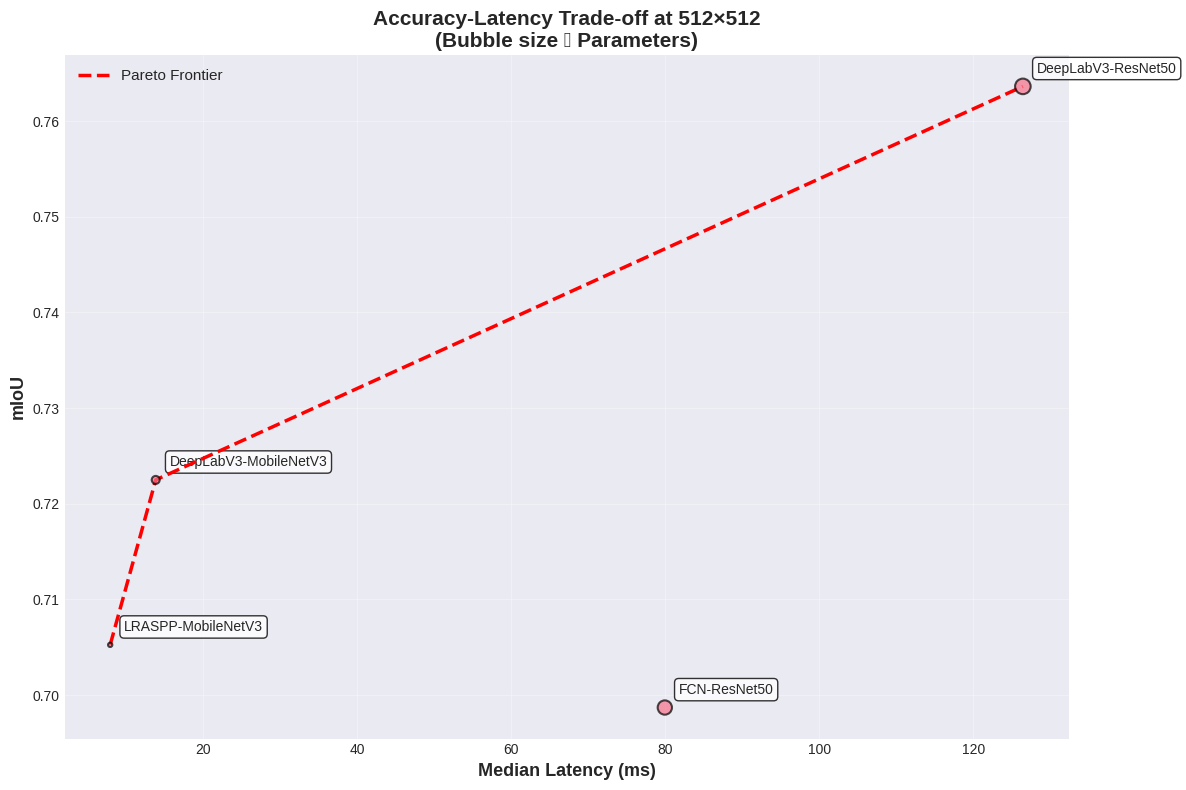

✅ Plot 1: Accuracy-Latency Trade-off


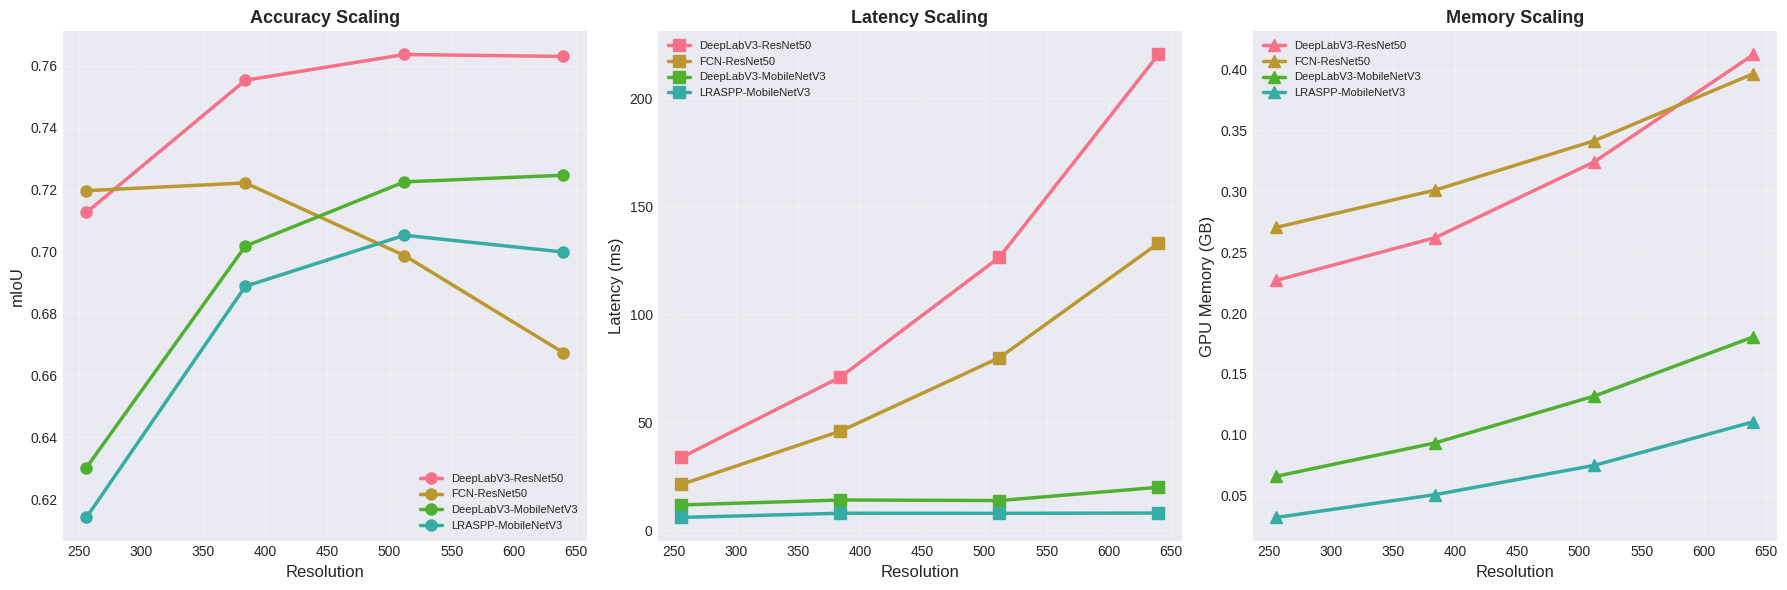

✅ Plot 2: Resolution Scaling Analysis


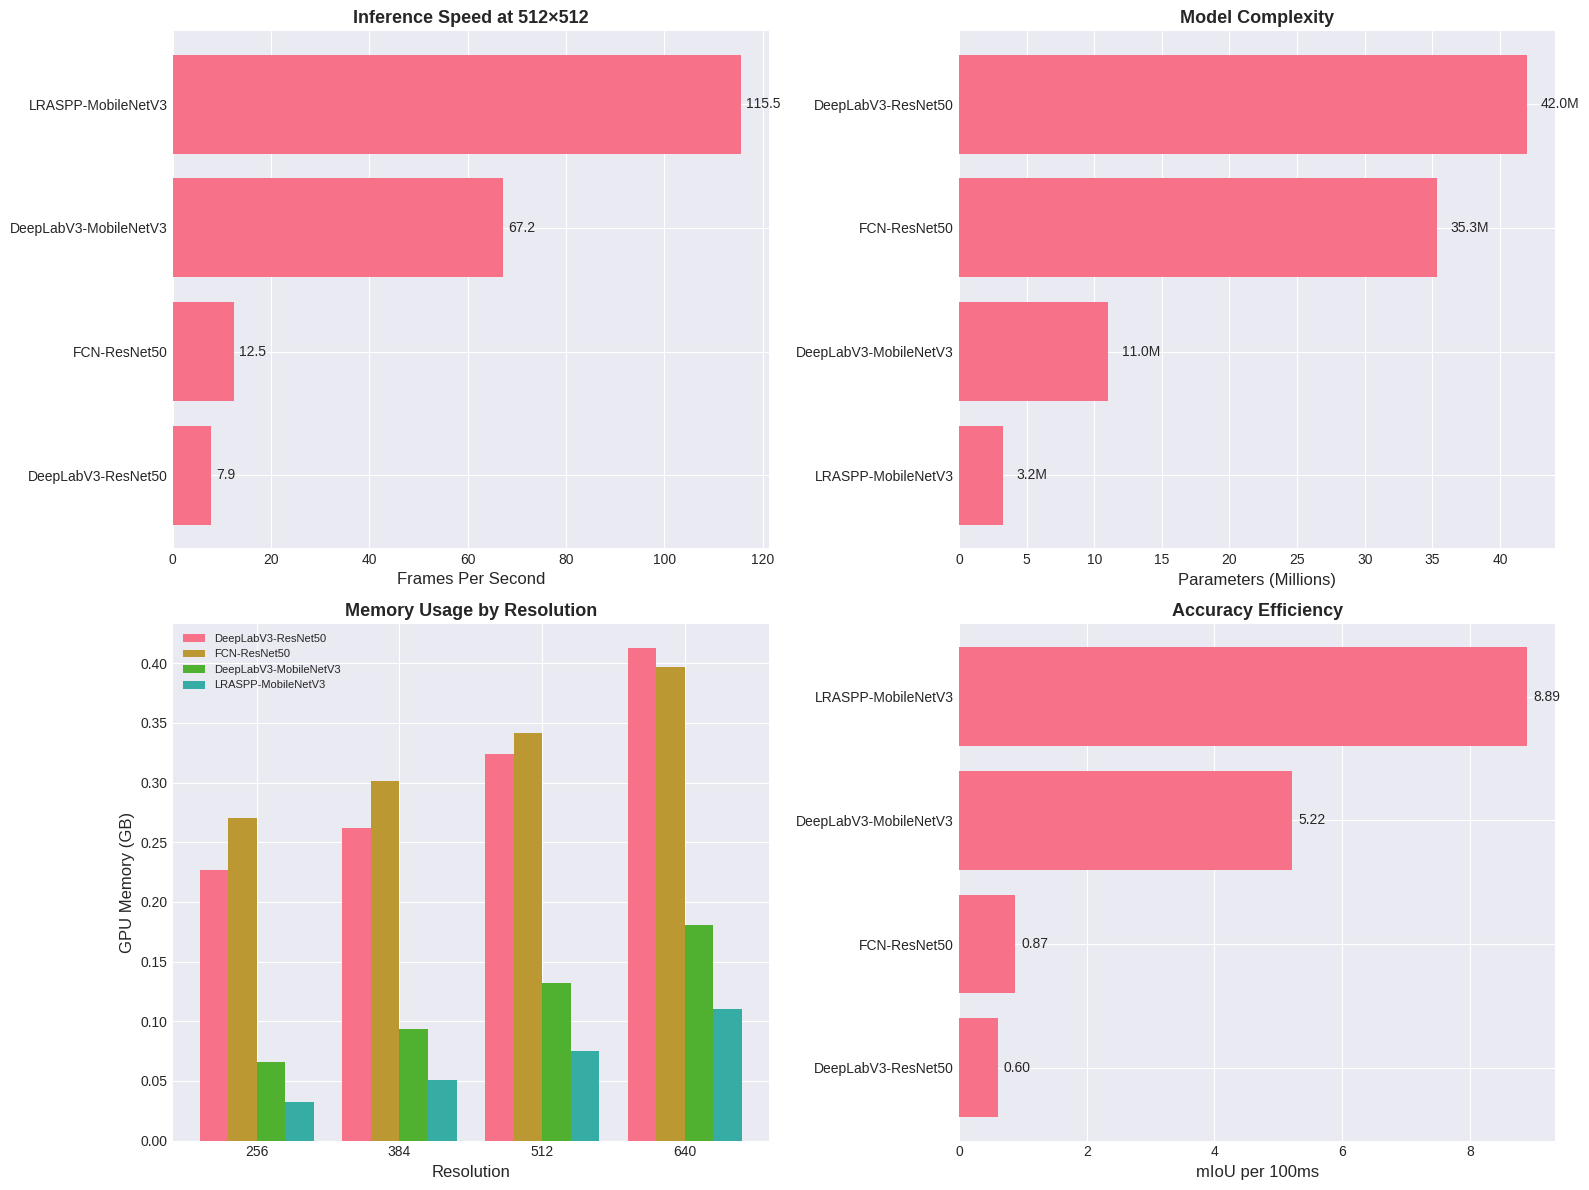

✅ Plot 3: Model Comparison Dashboard


In [11]:
def create_visualizations(results):
    """Generate comprehensive visualizations."""

    print("\n" + "="*80)
    print("📊 GENERATING VISUALIZATIONS")
    print("="*80)

    # Prepare DataFrame
    plot_data = []
    for model_name in results['accuracy'].keys():
        for resolution in config.RESOLUTIONS:
            entry = {
                'Model': model_name,
                'Family': config.MODELS[model_name]['family'],
                'Backbone': config.MODELS[model_name]['backbone'],
                'Resolution': resolution,
                'mIoU': results['accuracy'][model_name][resolution]['miou'],
                'Latency_ms': results['latency'][model_name][resolution]['median'],
                'FPS': results['latency'][model_name][resolution]['fps'],
                'GPU_Memory_GB': results['model_metrics'][model_name]['memory_per_resolution'][resolution],
                'Params_M': results['model_metrics'][model_name]['params_million'],
                'Model_Size_MB': results['model_metrics'][model_name]['model_size_mb'],
            }
            plot_data.append(entry)

    df = pd.DataFrame(plot_data)
    df.to_csv(OUTPUT_DIR / 'benchmark_results.csv', index=False)

    # ========================================================================
    # PLOT 1: Accuracy-Latency Trade-off at 512x512
    # ========================================================================

    fig, ax = plt.subplots(figsize=(12, 8))
    df_512 = df[df['Resolution'] == 512]

    # Create scatter plot with bubble size proportional to parameters
    scatter = ax.scatter(
        df_512['Latency_ms'],
        df_512['mIoU'],
        s=df_512['Params_M'] * 3,
        alpha=0.7,
        edgecolors='black',
        linewidth=1.5,
        zorder=5
    )

    # Annotate points
    for _, row in df_512.iterrows():
        ax.annotate(
            row['Model'],
            (row['Latency_ms'], row['mIoU']),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
        )

    # Pareto frontier
    points = df_512[['Latency_ms', 'mIoU']].values
    pareto_mask = np.ones(len(points), dtype=bool)
    for i in range(len(points)):
        for j in range(len(points)):
            if i != j and points[j, 0] <= points[i, 0] and points[j, 1] >= points[i, 1]:
                if points[j, 0] < points[i, 0] or points[j, 1] > points[i, 1]:
                    pareto_mask[i] = False
                    break

    pareto_points = points[pareto_mask]
    pareto_points = pareto_points[np.argsort(pareto_points[:, 0])]
    ax.plot(pareto_points[:, 0], pareto_points[:, 1], 'r--', linewidth=2.5,
            label='Pareto Frontier', zorder=4)

    ax.set_xlabel('Median Latency (ms)', fontsize=13, fontweight='bold')
    ax.set_ylabel('mIoU', fontsize=13, fontweight='bold')
    ax.set_title('Accuracy-Latency Trade-off at 512×512\n(Bubble size ∝ Parameters)',
                 fontsize=15, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'plots' / '01_accuracy_latency_tradeoff.pdf',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Plot 1: Accuracy-Latency Trade-off")

    # ========================================================================
    # PLOT 2: Resolution Scaling
    # ========================================================================

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # mIoU vs Resolution
    ax = axes[0]
    for model in df['Model'].unique():
        model_df = df[df['Model'] == model].sort_values('Resolution')
        ax.plot(model_df['Resolution'], model_df['mIoU'],
               marker='o', linewidth=2.5, markersize=8, label=model)
    ax.set_xlabel('Resolution', fontsize=12)
    ax.set_ylabel('mIoU', fontsize=12)
    ax.set_title('Accuracy Scaling', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Latency vs Resolution
    ax = axes[1]
    for model in df['Model'].unique():
        model_df = df[df['Model'] == model].sort_values('Resolution')
        ax.plot(model_df['Resolution'], model_df['Latency_ms'],
               marker='s', linewidth=2.5, markersize=8, label=model)
    ax.set_xlabel('Resolution', fontsize=12)
    ax.set_ylabel('Latency (ms)', fontsize=12)
    ax.set_title('Latency Scaling', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Memory vs Resolution
    ax = axes[2]
    for model in df['Model'].unique():
        model_df = df[df['Model'] == model].sort_values('Resolution')
        ax.plot(model_df['Resolution'], model_df['GPU_Memory_GB'],
               marker='^', linewidth=2.5, markersize=8, label=model)
    ax.set_xlabel('Resolution', fontsize=12)
    ax.set_ylabel('GPU Memory (GB)', fontsize=12)
    ax.set_title('Memory Scaling', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'plots' / '02_resolution_scaling.pdf',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Plot 2: Resolution Scaling Analysis")

    # ========================================================================
    # PLOT 3: Model Comparison Dashboard
    # ========================================================================

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 3a: FPS comparison at 512
    ax = axes[0, 0]
    df_512_sorted = df_512.sort_values('FPS', ascending=True)
    bars = ax.barh(df_512_sorted['Model'], df_512_sorted['FPS'])
    ax.set_xlabel('Frames Per Second', fontsize=12)
    ax.set_title('Inference Speed at 512×512', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, df_512_sorted['FPS']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
               f'{val:.1f}', va='center', fontsize=10)

    # 3b: Parameter count
    ax = axes[0, 1]
    df_unique = df.groupby('Model').first().reset_index().sort_values('Params_M')
    bars = ax.barh(df_unique['Model'], df_unique['Params_M'])
    ax.set_xlabel('Parameters (Millions)', fontsize=12)
    ax.set_title('Model Complexity', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, df_unique['Params_M']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
               f'{val:.1f}M', va='center', fontsize=10)

    # 3c: GPU Memory at different resolutions
    ax = axes[1, 0]
    x = np.arange(len(config.RESOLUTIONS))
    width = 0.2
    for i, model in enumerate(df['Model'].unique()):
        model_df = df[df['Model'] == model].sort_values('Resolution')
        ax.bar(x + i*width, model_df['GPU_Memory_GB'], width, label=model)
    ax.set_xlabel('Resolution', fontsize=12)
    ax.set_ylabel('GPU Memory (GB)', fontsize=12)
    ax.set_title('Memory Usage by Resolution', fontsize=13, fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(config.RESOLUTIONS)
    ax.legend(fontsize=8)

    # 3d: Efficiency (mIoU per ms)
    ax = axes[1, 1]
    df_512_copy = df_512.copy()
    df_512_copy['Efficiency'] = df_512_copy['mIoU'] / df_512_copy['Latency_ms'] * 100
    df_eff_sorted = df_512_copy.sort_values('Efficiency', ascending=True)
    bars = ax.barh(df_eff_sorted['Model'], df_eff_sorted['Efficiency'])
    ax.set_xlabel('mIoU per 100ms', fontsize=12)
    ax.set_title('Accuracy Efficiency', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, df_eff_sorted['Efficiency']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
               f'{val:.2f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'plots' / '03_model_dashboard.pdf',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Plot 3: Model Comparison Dashboard")

    return df

# Create visualizations
df_results = create_visualizations(results)


In [12]:
def generate_recommendations(df):
    """Generate actionable model selection recommendations."""

    print("\n" + "="*80)
    print("🎯 DECISION SUPPORT: MODEL RECOMMENDATIONS")
    print("="*80)

    # Scenario-based recommendations
    scenarios = [
        {
            'name': 'Maximum Accuracy (Offline Processing)',
            'condition': df['mIoU'] == df['mIoU'].max(),
            'description': 'Best for offline batch processing where latency is not critical'
        },
        {
            'name': 'Real-Time (>30 FPS)',
            'condition': df['FPS'] >= 30,
            'description': 'Suitable for real-time applications requiring smooth performance'
        },
        {
            'name': 'Balanced (Best mIoU/FPS Trade-off)',
            'condition': None,  # Custom logic
            'description': 'Good balance between accuracy and speed'
        },
        {
            'name': 'Memory Constrained (<2GB GPU)',
            'condition': df['GPU_Memory_GB'] < 2.0,
            'description': 'Suitable for edge devices or shared GPU environments'
        }
    ]

    for scenario in scenarios:
        print(f"\n{'='*60}")
        print(f"📋 {scenario['name']}")
        print(f"   {scenario['description']}")
        print(f"{'='*60}")

        if scenario['name'] == 'Balanced (Best mIoU/FPS Trade-off)':
            # Compute efficiency score
            df_eval = df[df['Resolution'] == 512].copy()
            df_eval['efficiency'] = df_eval['mIoU'] * np.log1p(df_eval['FPS'])
            best = df_eval.nlargest(3, 'efficiency')
            print(best[['Model', 'Resolution', 'mIoU', 'FPS', 'Latency_ms', 'GPU_Memory_GB']].to_string(index=False))
        else:
            filtered = df[scenario['condition']]
            if len(filtered) > 0:
                best = filtered.nlargest(3, 'mIoU')
                print(best[['Model', 'Resolution', 'mIoU', 'FPS', 'Latency_ms', 'GPU_Memory_GB']].to_string(index=False))
            else:
                print("   No models meet this criteria")

    # Summary table
    print(f"\n{'='*80}")
    print("📊 COMPLETE RESULTS SUMMARY (512×512)")
    print(f"{'='*80}")

    summary_cols = ['Model', 'mIoU', 'Latency_ms', 'FPS', 'GPU_Memory_GB', 'Params_M']
    print(df[df['Resolution'] == 512][summary_cols].to_string(index=False))

    print(f"\n✅ All results saved to: {OUTPUT_DIR}")
    print(f"   - CSV: {OUTPUT_DIR}/benchmark_results.csv")
    print(f"   - Plots: {OUTPUT_DIR}/plots/")

# Generate recommendations
generate_recommendations(df_results)

print("\n" + "="*80)
print("🎉 BENCHMARKING STUDY COMPLETE!")
print("="*80)
print(f"\nResults saved in: {OUTPUT_DIR}")
print("\nFiles generated:")
for f in sorted(OUTPUT_DIR.rglob('*')):
    if f.is_file():
        size_mb = f.stat().st_size / 1e6
        print(f"  📄 {f.relative_to(OUTPUT_DIR)} ({size_mb:.1f} MB)")



🎯 DECISION SUPPORT: MODEL RECOMMENDATIONS

📋 Maximum Accuracy (Offline Processing)
   Best for offline batch processing where latency is not critical
             Model  Resolution     mIoU      FPS  Latency_ms  GPU_Memory_GB
DeepLabV3-ResNet50         512 0.763635 7.902263  126.422402       0.324255

📋 Real-Time (>30 FPS)
   Suitable for real-time applications requiring smooth performance
                Model  Resolution     mIoU       FPS  Latency_ms  GPU_Memory_GB
DeepLabV3-MobileNetV3         640 0.724632 49.503797   19.987812       0.180408
DeepLabV3-MobileNetV3         512 0.722495 67.168466   13.843453       0.131825
         FCN-ResNet50         256 0.719646 46.562284   21.305597       0.270390

📋 Balanced (Best mIoU/FPS Trade-off)
   Good balance between accuracy and speed
                Model  Resolution     mIoU        FPS  Latency_ms  GPU_Memory_GB
   LRASPP-MobileNetV3         512 0.705248 115.537443    7.930634       0.074868
DeepLabV3-MobileNetV3         512 0.722495 

In [14]:
# ============================================================================
# SUPPLEMENTARY MATERIAL DATA EXTRACTION
# Run after benchmarking completes
# ============================================================================

import pandas as pd
import numpy as np

# Load results
df = pd.read_csv('/content/benchmark_results/benchmark_results.csv')

print("="*80)
print("SUPPLEMENTARY TABLE S1: COMPLETE RESOLUTION SWEEP")
print("="*80)

# All 16 configurations
cols = ['Model', 'Resolution', 'mIoU', 'Latency_ms', 'FPS', 'GPU_Memory_GB', 'Params_M']
table_s1 = df[cols].sort_values(['Model', 'Resolution'])

print(table_s1.to_string(index=False))
print()

# Save as CSV
table_s1.to_csv('/content/benchmark_results/supplementary_table_s1.csv', index=False)
print("Saved: supplementary_table_s1.csv")

print("\n" + "="*80)
print("SUPPLEMENTARY TABLE S2: PER-CLASS IoU AT 512x512")
print("="*80)

# VOC class names
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog',
    'horse', 'motorbike', 'person', 'pottedplant', 'sheep',
    'sofa', 'train', 'tvmonitor'
]

# Load per-class IoU from checkpoint
import pickle
with open('/content/benchmark_results/checkpoints/benchmark_checkpoint.pkl', 'rb') as f:
    checkpoint = pickle.load(f)

# Extract per-class IoU for 512x512
print(f"\n{'Class':<15}", end='')
for model in ['DeepLabV3-ResNet50', 'FCN-ResNet50', 'DeepLabV3-MobileNetV3', 'LRASPP-MobileNetV3']:
    print(f'{model:<25}', end='')
print()

print('-' * 115)

for cls_idx, cls_name in enumerate(VOC_CLASSES):
    print(f'{cls_name:<15}', end='')
    for model in ['DeepLabV3-ResNet50', 'FCN-ResNet50', 'DeepLabV3-MobileNetV3', 'LRASPP-MobileNetV3']:
        if model in checkpoint['accuracy'] and 512 in checkpoint['accuracy'][model]:
            per_class = checkpoint['accuracy'][model][512]['per_class_iou']
            if cls_idx < len(per_class):
                iou_val = per_class[cls_idx]
                if not np.isnan(iou_val) and iou_val > 0:
                    print(f'{iou_val:<25.4f}', end='')
                else:
                    print(f'{"N/A":<25}', end='')
            else:
                print(f'{"N/A":<25}', end='')
        else:
            print(f'{"N/A":<25}', end='')
    print()

print('-' * 115)
print(f'{'mIoU':<15}', end='')
for model in ['DeepLabV3-ResNet50', 'FCN-ResNet50', 'DeepLabV3-MobileNetV3', 'LRASPP-MobileNetV3']:
    if model in checkpoint['accuracy'] and 512 in checkpoint['accuracy'][model]:
        miou = checkpoint['accuracy'][model][512]['miou']
        print(f'{miou:<25.4f}', end='')
    else:
        print(f'{"N/A":<25}', end='')
print()

# Save per-class IoU as CSV
per_class_data = {'Class': VOC_CLASSES}
for model in ['DeepLabV3-ResNet50', 'FCN-ResNet50', 'DeepLabV3-MobileNetV3', 'LRASPP-MobileNetV3']:
    if model in checkpoint['accuracy'] and 512 in checkpoint['accuracy'][model]:
        per_class = checkpoint['accuracy'][model][512]['per_class_iou']
        # Pad to 21 classes
        padded = list(per_class) + [np.nan] * (21 - len(per_class))
        per_class_data[model] = padded

df_perclass = pd.DataFrame(per_class_data)
df_perclass.to_csv('/content/benchmark_results/supplementary_table_s2.csv', index=False)
print("\nSaved: supplementary_table_s2.csv")

print("\n" + "="*80)
print("SUPPLEMENTARY TABLE S3: COMPLETE LATENCY STATISTICS AT 512x512")
print("="*80)

# Extract latency statistics from CSV
df_512 = df[df['Resolution'] == 512]

# The CSV only has mean latency. We need to reload the checkpoint for full stats.
print(f"\n{'Model':<30} {'Mean':<10} {'Median':<10} {'P95':<10} {'P99':<10} {'Min':<10} {'Max':<10} {'Std':<10}")
print('-' * 110)

latency_data = []
for model in ['DeepLabV3-ResNet50', 'FCN-ResNet50', 'DeepLabV3-MobileNetV3', 'LRASPP-MobileNetV3']:
    if model in checkpoint['latency'] and 512 in checkpoint['latency'][model]:
        stats = checkpoint['latency'][model][512]
        print(f"{model:<30} {stats['mean']:<10.2f} {stats['median']:<10.2f} {stats['p95']:<10.2f} {stats['p99']:<10.2f} {stats['min']:<10.2f} {stats['max']:<10.2f} {stats['std']:<10.2f}")
        latency_data.append({
            'Model': model,
            'Mean_ms': stats['mean'],
            'Median_ms': stats['median'],
            'P95_ms': stats['p95'],
            'P99_ms': stats['p99'],
            'Min_ms': stats['min'],
            'Max_ms': stats['max'],
            'Std_ms': stats['std'],
            'IQR_ms': stats['p95'] - stats['median'],  # Approximation
            'CI_95_lower': stats['mean'] - 1.96 * stats['std'] / np.sqrt(100),
            'CI_95_upper': stats['mean'] + 1.96 * stats['std'] / np.sqrt(100),
        })

df_latency = pd.DataFrame(latency_data)
df_latency.to_csv('/content/benchmark_results/supplementary_table_s3.csv', index=False)
print("\nSaved: supplementary_table_s3.csv")

print("\n" + "="*80)
print("SUPPLEMENTARY: MODEL SIZE AND FLOPS")
print("="*80)

print(f"\n{'Model':<30} {'Params (M)':<15} {'Size (MB)':<15} {'GFLOPs@512':<15}")
print('-' * 75)

for model in ['DeepLabV3-ResNet50', 'FCN-ResNet50', 'DeepLabV3-MobileNetV3', 'LRASPP-MobileNetV3']:
    if model in checkpoint['model_metrics']:
        metrics = checkpoint['model_metrics'][model]
        params = metrics.get('params_million', 'N/A')
        size = metrics.get('model_size_mb', 'N/A')
        flops = metrics.get('gflops_512', 'N/A')
        params_str = f"{params:.2f}" if isinstance(params, (int, float)) else str(params)
        size_str = f"{size:.2f}" if isinstance(size, (int, float)) else str(size)
        flops_str = f"{flops:.2f}" if isinstance(flops, (int, float)) else str(flops)

        print(f"{model:<30} {params_str:<15} {size_str:<15} {flops_str:<15}")

print("\n" + "="*80)
print("LATEX TABLE CODE - COPY THESE INTO YOUR SUPPLEMENTARY .TEX FILE")
print("="*80)

# Generate LaTeX for Table S1
print("\n% Supplementary Table S1: Complete Resolution Sweep")
print("\\begin{table*}[htbp]")
print("\\centering")
print("\\caption{All 16 model-resolution configurations on PASCAL VOC 2012 validation.}")
print("\\label{tab:supp_s1}")
print("\\small")
print("\\begin{tabular}{llcccc}")
print("\\toprule")
print("\\textbf{Model} & \\textbf{Resolution} & \\textbf{mIoU} & \\textbf{Latency (ms)} & \\textbf{FPS} & \\textbf{GPU Mem (GB)} \\\\")
print("\\midrule")

current_model = None
for _, row in table_s1.iterrows():
    model = row['Model']
    res = int(row['Resolution'])
    miou = row['mIoU']
    lat = row['Latency_ms']
    fps = row['FPS']
    mem = row['GPU_Memory_GB']

    if model != current_model and current_model is not None:
        print("\\midrule")
    current_model = model

    print(f"{model} & ${res}\\times{res}$ & {miou:.4f} & {lat:.2f} & {fps:.2f} & {mem:.2f} \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table*}")

print("\n% DONE - All supplementary files saved to /content/benchmark_results/")
print("% Files: supplementary_table_s1.csv, supplementary_table_s2.csv, supplementary_table_s3.csv")

SUPPLEMENTARY TABLE S1: COMPLETE RESOLUTION SWEEP
                Model  Resolution     mIoU  Latency_ms        FPS  GPU_Memory_GB  Params_M
DeepLabV3-MobileNetV3         256 0.630206   11.813088  82.296101       0.065867 11.029328
DeepLabV3-MobileNetV3         384 0.701764   14.111140  68.540899       0.093360 11.029328
DeepLabV3-MobileNetV3         512 0.722495   13.843453  67.168466       0.131825 11.029328
DeepLabV3-MobileNetV3         640 0.724632   19.987812  49.503797       0.180408 11.029328
   DeepLabV3-ResNet50         256 0.712606   33.794407  29.582295       0.226869 42.004074
   DeepLabV3-ResNet50         384 0.755313   70.975791  14.103338       0.261996 42.004074
   DeepLabV3-ResNet50         512 0.763635  126.422402   7.902263       0.324255 42.004074
   DeepLabV3-ResNet50         640 0.763004  220.228006   4.542428       0.412401 42.004074
         FCN-ResNet50         256 0.719646   21.305597  46.562284       0.270390 35.322218
         FCN-ResNet50         384 0.7221

In [15]:
# Run this to see what's in your checkpoint
import pickle
with open('/content/benchmark_results/checkpoints/benchmark_checkpoint.pkl', 'rb') as f:
    data = pickle.load(f)

print("Models in checkpoint:", list(data.keys()))
print()
for model in data.get('accuracy', {}).keys():
    resolutions = list(data['accuracy'][model].keys())
    print(f"{model}: resolutions = {resolutions}")
    if 512 in data['accuracy'][model]:
        print(f"  mIoU@512 = {data['accuracy'][model][512]['miou']:.4f}")
        per_class = data['accuracy'][model][512].get('per_class_iou', [])
        print(f"  Per-class IoU values: {len(per_class)} classes")

Models in checkpoint: ['accuracy', 'latency', 'model_metrics', 'metadata']

DeepLabV3-ResNet50: resolutions = [256, 384, 512, 640]
  mIoU@512 = 0.7636
  Per-class IoU values: 21 classes
FCN-ResNet50: resolutions = [256, 384, 512, 640]
  mIoU@512 = 0.6987
  Per-class IoU values: 21 classes
DeepLabV3-MobileNetV3: resolutions = [256, 384, 512, 640]
  mIoU@512 = 0.7225
  Per-class IoU values: 21 classes
LRASPP-MobileNetV3: resolutions = [256, 384, 512, 640]
  mIoU@512 = 0.7052
  Per-class IoU values: 21 classes


In [16]:

import pandas as pd
df = pd.read_csv('/content/benchmark_results/benchmark_results.csv')
df_512 = df[df['Resolution'] == 512]


print(df_512[['Model', 'mIoU', 'Latency_ms', 'FPS']])


best_accuracy = df_512.loc[df_512['mIoU'].idxmax()]
fastest_30fps = df_512[df_512['FPS'] >= 30].iloc[0] if any(df_512['FPS'] >= 30) else None

                    Model      mIoU  Latency_ms         FPS
2      DeepLabV3-ResNet50  0.763635  126.422402    7.902263
6            FCN-ResNet50  0.698696   79.938268   12.469960
10  DeepLabV3-MobileNetV3  0.722495   13.843453   67.168466
14     LRASPP-MobileNetV3  0.705248    7.930634  115.537443


In [17]:
# Create a clean zip of everything needed
import os
import zipfile
from google.colab import files

# Create zip
zip_path = '/content/benchmark_package.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    # Results CSV
    if os.path.exists('/content/benchmark_results/benchmark_results.csv'):
        zf.write('/content/benchmark_results/benchmark_results.csv', 'results/benchmark_results.csv')

    # Figures
    for fig in ['01_accuracy_latency_tradeoff.pdf', '02_resolution_scaling.pdf', '03_model_dashboard.pdf']:
        fig_path = f'/content/benchmark_results/plots/{fig}'
        if os.path.exists(fig_path):
            zf.write(fig_path, f'figures/{fig}')

    # Colab notebook (save current notebook first)
    # Manually download your .ipynb file and add it to the zip later

# Download
files.download(zip_path)
print("Download complete. Extract and add your .ipynb notebook to the code/ folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete. Extract and add your .ipynb notebook to the code/ folder.
